In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import copy

from tqdm import tqdm
from docx import Document
from docx.shared import Inches
from docx.enum.text import WD_PARAGRAPH_ALIGNMENT, WD_ALIGN_PARAGRAPH

import Flexivan_Prediction_Package

In [2]:
# Get filenames from folder
print('Getting PAST raw data filenames...')
DATA_Folder = '/root/Flexivan/Flexivan/Daily prediction/DATA'

FILENAMES = [f for f in os.listdir(DATA_Folder) if os.path.isfile(os.path.join(DATA_Folder, f))]
selected = "Latest_Test_"
selected2 = '_DETAILED'
FILENAMES = [f for f in FILENAMES if selected in f and selected2 not in f]
DATES = Flexivan_Prediction_Package.extract_datetimes_from_filenames(FILENAMES)
Filenames_DF = pd.DataFrame({
    "Filenames": FILENAMES,
    "Dates": DATES
})
Filenames_DF_Sorted = Filenames_DF.sort_values(by='Dates')
FILENAMES = list(Filenames_DF_Sorted['Filenames'])
DATES = list(Filenames_DF_Sorted['Dates'])

print(f'DONE - {len(FILENAMES)} Filenames were found')


#endregion


Getting PAST raw data filenames...
DONE - 250 Filenames were found


In [7]:
Range = DATES[len(DATES)-1] - DATES[0]
print(DATES[0])
print(DATES[len(DATES)-1])
print(Range)

2025-02-16 00:00:00
2025-11-02 00:00:00
259 days 00:00:00


Laoding files for STATS generation...


100%|██████████| 250/250 [02:44<00:00,  1.52it/s]


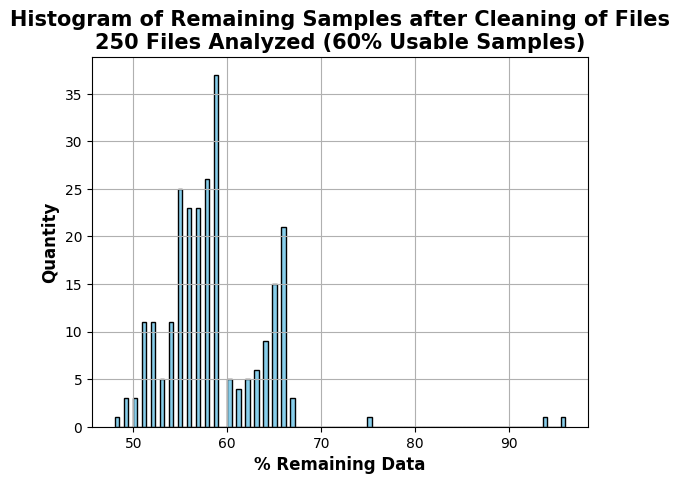

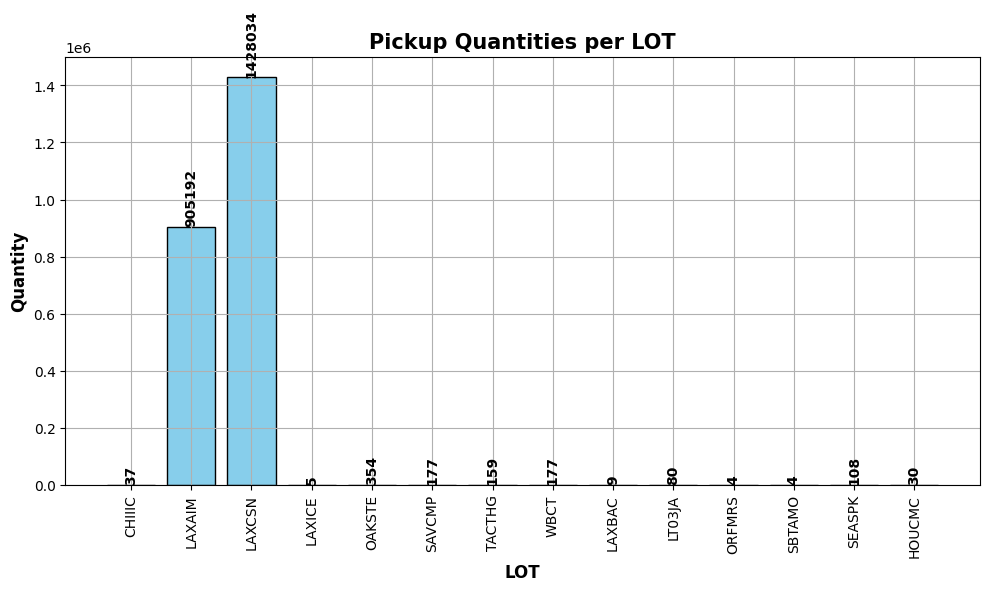

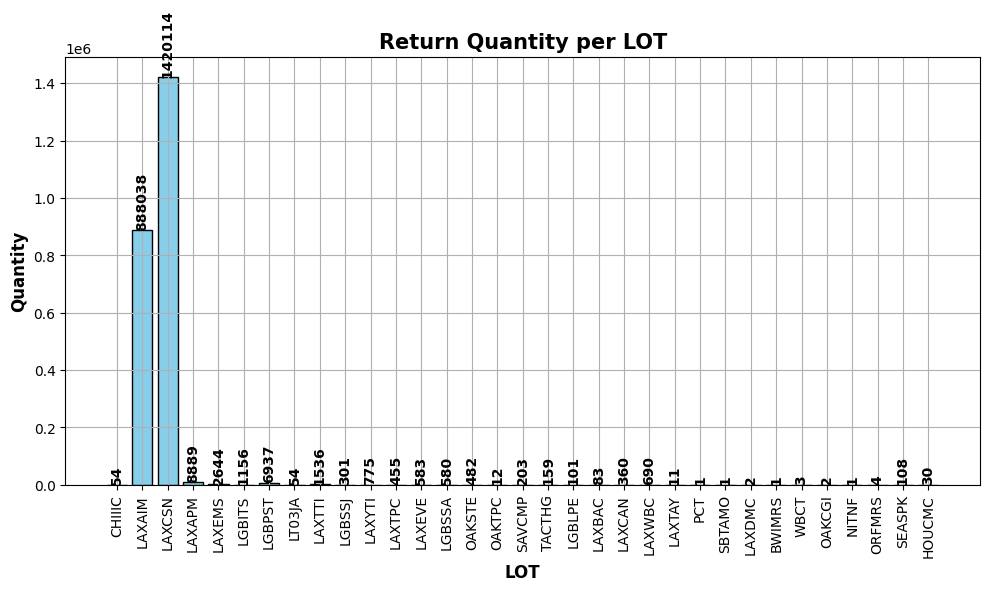

In [32]:
# Analyze file stats

Pickup_LOT_Field_Name = 'CHS Pickup Loc'
Return_LOT_Field_Name = 'CHS Return Loc'
Sorting_Field = copy.deepcopy(Pickup_LOT_Field_Name)

Columns_2_Drop_From_Training = ['CHS ID', 'CTR Trip Id', 'CHS Return Dt', 'CHS Pickup Date', 'CTR pick Dt', 'CTR Return Dt']
Enumerated_Columns_LIST = ['CHS Pickup Loc', 'CHS Return Loc', 'CHS pickup MCO', 'CTR Trip MCO', 'O Customer', 'Customer', 'DC Loc', 'CTR Pickup Term', 'CTR Return Term', 
                           'pgkey', 'CTR Trip Loc Type Pattern', 'CTR Trip Pattern']

print('Laoding files for STATS generation...')
STATS_DF = pd.DataFrame(columns=['Filename', 'Original_Lines_No', 'Lines_No_After_Cleaning', 'Percentage'])
file_index = 0

LOT_Appearance_MAP = {}
Total_Usable_Data = 0
Total_Data = 0

PU_LOT_Apperance_Quantity = {}
Return_LOT_Apperance_Quantity = {}

for filename in tqdm(FILENAMES):
    # Clean data and collect remainder samples stats
    File_Analysis_Results_OBJ = Flexivan_Prediction_Package.File_Analysis_Reults(f'{DATA_Folder}/{filename}', Sorting_Field, Columns_2_Drop_From_Training, Enumerated_Columns_LIST)
    Total_Data += len(File_Analysis_Results_OBJ.DATA_ORIG)
    Total_Usable_Data += len(File_Analysis_Results_OBJ.DATA)

    ROW = [filename, len(File_Analysis_Results_OBJ.DATA_ORIG), len(File_Analysis_Results_OBJ.DATA), \
        int(100*len(File_Analysis_Results_OBJ.DATA)/len(File_Analysis_Results_OBJ.DATA_ORIG))]

    STATS_DF.loc[len(STATS_DF)] = ROW

    PU_Lots_Unique = list(File_Analysis_Results_OBJ.DATA[Pickup_LOT_Field_Name].unique())
    Return_Lots_Unique = list(File_Analysis_Results_OBJ.DATA[Return_LOT_Field_Name].unique())

    #region Collect Pickup LOT appearance data
    for pu_lot in PU_Lots_Unique:
        DATA = File_Analysis_Results_OBJ.DATA[File_Analysis_Results_OBJ.DATA[Pickup_LOT_Field_Name]==pu_lot]
        try:
            PU_LOT_Apperance_Quantity[pu_lot] += len(DATA)
        except:
            PU_LOT_Apperance_Quantity[pu_lot] = len(DATA)
    #endregion

    #region Collect Return LOT appearance data
    for return_lot in Return_Lots_Unique:
        DATA = File_Analysis_Results_OBJ.DATA[File_Analysis_Results_OBJ.DATA[Return_LOT_Field_Name]==return_lot]
        try:
            Return_LOT_Apperance_Quantity[return_lot] += len(DATA)
        except:
            Return_LOT_Apperance_Quantity[return_lot] = len(DATA)
    #endregion

    file_index += 1
    # if file_index>=3:
    #     break

#region Display remaining data percentage
plt.hist(np.array(STATS_DF['Percentage']), bins=100, color='skyblue', edgecolor='black')
plt.xlabel('% Remaining Data', fontsize=12, fontweight='bold')
plt.ylabel('Quantity', fontsize=12, fontweight='bold')
plt.title(f'Histogram of Remaining Samples after Cleaning of Files\n{len(FILENAMES)} Files Analyzed ({int(100*Total_Usable_Data/Total_Data)}% Usable Samples)', fontsize=15, fontweight='bold')
plt.grid()
#endregion

#region Display pickup quantities for each LOT

categories = []
values = []

for key in PU_LOT_Apperance_Quantity.keys():
    categories.append(str(key))
    values.append(PU_LOT_Apperance_Quantity[key])

# Create bar plot
# Create figure with custom size
plt.figure(figsize=(10, 6))

# Create bar plot
bars = plt.bar(categories, values, color='skyblue', edgecolor='black')

# Rotate x-axis labels 90 degrees
plt.xticks(rotation=90)

# Add value labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        x=bar.get_x() + bar.get_width() / 2,  # center of the bar
        y=height + 3,                        # slightly above the bar
        s=str(height),                          # value text
        ha='center',                            # horizontal alignment
        va='bottom',                            # vertical alignment
        rotation=90,                               # vertical alignment
        fontweight='bold'
    )

# Optional: axis labels and title
plt.xlabel('LOT', fontweight='bold', fontsize=12)
plt.ylabel('Quantity', fontweight='bold', fontsize=12)
plt.title('Pickup Quantities per LOT', fontweight='bold', fontsize=15)

plt.tight_layout() 
plt.grid()
#endregion

#region Display returns quantities for each LOT

categories = []
values = []

for key in Return_LOT_Apperance_Quantity.keys():
    categories.append(str(key))
    values.append(Return_LOT_Apperance_Quantity[key])

# Create figure with custom size
plt.figure(figsize=(10, 6))

# Create bar plot
bars = plt.bar(categories, values, color='skyblue', edgecolor='black')

# Rotate x-axis labels 90 degrees
plt.xticks(rotation=90)

# Add value labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        x=bar.get_x() + bar.get_width() / 2,  # center of the bar
        y=height + 3,                        # slightly above the bar
        s=str(height),                          # value text
        ha='center',                            # horizontal alignment
        va='bottom',                            # vertical alignment
        rotation=90,                               # vertical alignment
        fontweight='bold'
    )

# Optional: axis labels and title
plt.xlabel('LOT', fontweight='bold', fontsize=12)
plt.ylabel('Quantity', fontweight='bold', fontsize=12)
plt.title('Return Quantity per LOT', fontweight='bold', fontsize=15)

plt.tight_layout() 
plt.grid()

#endregion

plt.show()

3881805